In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

BASE_DIR = Path(".").resolve()

import sys
sys.path.insert(0, str(BASE_DIR.parent.parent / "modelling/shared"))
from hb_shared_utils import compute_wca, build_regressors

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

INPUT_DIR_PANEL = BASE_DIR.parent.parent
INPUT_DIR_CFO_FORECASTS = BASE_DIR.parent.parent / "data/raw_data_lseg"
raw = pd.read_csv(INPUT_DIR_CFO_FORECASTS / "cfo_forecasts_monthly_raw.csv")
raw = raw.assign(snapshot_date=pd.to_datetime(raw["snapshot_date"]))

print(f"Raw rows:        {len(raw):,}")
print(f"Unique tickers:  {raw['Ticker'].nunique()}")
print(f"Date range:      {raw['snapshot_date'].min().date()} to {raw['snapshot_date'].max().date()}")

# Dedup same-day duplicates (FY rolling artifacts) — keep last value per (Ticker, date)
n_before = len(raw)
raw = raw.sort_values(["Ticker", "snapshot_date"])
raw = (
    raw.groupby(["Ticker", "snapshot_date"], as_index=False)["cfo_forecast"]
       .mean()
)
print(f"After dedup:     {len(raw):,}  ({n_before - len(raw)} same-day duplicates removed)")

# Filter unrealistic outliers (data errors, not real forecasts)
# Look at the percentile range first
print("\nForecast value percentiles:")
print(raw["cfo_forecast"].describe(percentiles=[0.001, 0.01, 0.99, 0.999]).round(2))

Raw rows:        33,539
Unique tickers:  574
Date range:      2013-07-19 to 2025-12-31
After dedup:     33,108  (431 same-day duplicates removed)

Forecast value percentiles:
count     33108.00
mean       2702.55
std        7404.67
min       -7219.00
0.1%      -1639.45
1%         -330.21
50%         409.90
99%       35526.10
99.9%     85172.11
max      146407.25
Name: cfo_forecast, dtype: float64


In [2]:
raw = raw.assign(
    Year=raw["snapshot_date"].dt.year,
    Month=raw["snapshot_date"].dt.month,
)

# Method A: Mean per calendar year (smoothest, your supervisor's suggestion)
annual_mean = (
    raw.groupby(["Ticker", "Year"])["cfo_forecast"]
    .mean().reset_index()
    .rename(columns={"cfo_forecast": "cfo_forecast_mean", "Year": "FiscalYear"})
)

# Method B: Median per year (robust to monthly outliers)
annual_median = (
    raw.groupby(["Ticker", "Year"])["cfo_forecast"]
    .median().reset_index()
    .rename(columns={"cfo_forecast": "cfo_forecast_median", "Year": "FiscalYear"})
)

# Method C: Last observation per year (most informed; closest to year-end)
annual_last = (
    raw.sort_values(["Ticker", "Year", "snapshot_date"])
    .groupby(["Ticker", "Year"], as_index=False)
    .last()[["Ticker", "Year", "cfo_forecast"]]
    .rename(columns={"cfo_forecast": "cfo_forecast_last", "Year": "FiscalYear"})
)

# Method D: Specific month (e.g., June)
annual_jun = raw.loc[raw["Month"] == 6, ["Ticker", "Year", "cfo_forecast"]].copy()
annual_jun = annual_jun.rename(columns={"cfo_forecast": "cfo_forecast_jun", "Year": "FiscalYear"})
annual_jun = annual_jun.drop_duplicates(subset=["Ticker", "FiscalYear"], keep="last")

# Merge all methods into one frame
annual = (annual_mean
    .merge(annual_median, on=["Ticker", "FiscalYear"], how="outer")
    .merge(annual_last,   on=["Ticker", "FiscalYear"], how="outer")
    .merge(annual_jun,    on=["Ticker", "FiscalYear"], how="outer"))

# Quick check — how correlated are the four methods?
print(annual[["cfo_forecast_mean","cfo_forecast_median","cfo_forecast_last","cfo_forecast_jun"]].corr().round(3))

                     cfo_forecast_mean  cfo_forecast_median  \
cfo_forecast_mean                1.000                1.000   
cfo_forecast_median              1.000                1.000   
cfo_forecast_last                0.995                0.995   
cfo_forecast_jun                 0.999                0.999   

                     cfo_forecast_last  cfo_forecast_jun  
cfo_forecast_mean                0.995             0.999  
cfo_forecast_median              0.995             0.999  
cfo_forecast_last                1.000             0.992  
cfo_forecast_jun                 0.992             1.000  


In [3]:
# Load your existing panel (the one used by your two-step model)

panel = pd.read_csv(INPUT_DIR_PANEL / "results/extraction_static/prepared_step2_input.csv")
panel = compute_wca(panel)
panel = build_regressors(panel, include_lead=True)

panel["avg_assets"] = (panel["AT"] + panel.groupby("Ticker")["AT"].shift(1)) / 2

# Merge analyst forecast onto panel.
forecast = annual.copy()
forecast["Year"] = forecast["FiscalYear"] - 1   # row Year=Y has forecast for Y+1

panel = panel.merge(
    forecast[["Ticker","Year","cfo_forecast_mean"]],
    on=["Ticker","Year"], how="left",
)

# Scale the forecast using the same denominator as CFO_scaled
panel["cfo_forecast_scaled"] = panel["cfo_forecast_mean"] / panel["avg_assets"]

# Compare analyst forecast (scaled) to realized CFO_{t+1} (scaled)
val = panel.dropna(subset=["cfo_forecast_scaled", "CFO_lead1_scaled"]).copy()

print(f"Validation sample: {len(val)} firm-years with both forecast and realized")
print(f"Years covered: {val['Year'].min()}–{val['Year'].max()}")
print(f"Unique firms: {val['Ticker'].nunique()}")

# Forecast errors
val["error"] = val["cfo_forecast_scaled"] - val["CFO_lead1_scaled"]
val["abs_error"] = val["error"].abs()
val["pct_error"] = val["error"] / val["CFO_lead1_scaled"].abs()

print("\nForecast accuracy (scaled CFO):")
print(f"  RMSE:               {np.sqrt((val['error']**2).mean()):.4f}")
print(f"  MAE:                {val['abs_error'].mean():.4f}")
print(f"  Median |error|:     {val['abs_error'].median():.4f}")
print(f"  Mean error (bias):  {val['error'].mean():+.4f}")
print(f"  Pearson r:          {pearsonr(val['cfo_forecast_scaled'], val['CFO_lead1_scaled'])[0]:.3f}")
print(f"  Spearman ρ:         {spearmanr(val['cfo_forecast_scaled'], val['CFO_lead1_scaled'])[0]:.3f}")

Validation sample: 4454 firm-years with both forecast and realized
Years covered: 2012–2023
Unique firms: 561

Forecast accuracy (scaled CFO):
  RMSE:               0.2006
  MAE:                0.0838
  Median |error|:     0.0445
  Mean error (bias):  -0.0252
  Pearson r:          0.735
  Spearman ρ:         0.573


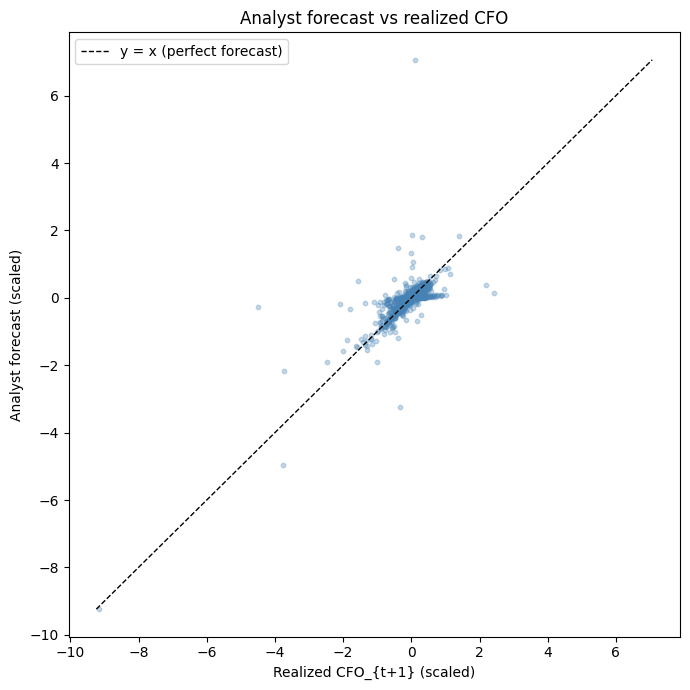

In [4]:
# Visual check: scatter of forecast vs realized
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(val["CFO_lead1_scaled"], val["cfo_forecast_scaled"], 
           alpha=0.3, s=10, color="steelblue")
lims = [val[["CFO_lead1_scaled","cfo_forecast_scaled"]].min().min(),
        val[["CFO_lead1_scaled","cfo_forecast_scaled"]].max().max()]
ax.plot(lims, lims, "k--", lw=1, label="y = x (perfect forecast)")
ax.set_xlabel("Realized CFO_{t+1} (scaled)")
ax.set_ylabel("Analyst forecast (scaled)")
ax.set_title("Analyst forecast vs realized CFO")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# ═══ Coverage diagnostic: how many forecast years are missing per firm? ═══

# We're interested in coverage *within each firm's panel of realized CFO*.
# That tells us: of the firm-years for which DD-style accrual modelling is 
# meaningful, how many have an analyst forecast available?

# Take only firm-years where we have a realized CFO_lead1 (else AR(1)/analyst
# comparison isn't meaningful for that row anyway)
realized = panel.dropna(subset=["CFO_lead1_scaled"]).copy()

def coverage_per_firm(group):
    n_realized = len(group)
    n_with_forecast = group["cfo_forecast_scaled"].notna().sum()
    n_missing = n_realized - n_with_forecast
    first_year = int(group["Year"].min())
    last_year = int(group["Year"].max())
    
    # Years where we have realized but no forecast
    missing_years = sorted(group.loc[group["cfo_forecast_scaled"].isna(), "Year"]
                           .astype(int).tolist())
    
    return pd.Series({
        "n_realized_years":  n_realized,
        "n_with_forecast":   int(n_with_forecast),
        "n_missing":         int(n_missing),
        "coverage_pct":      n_with_forecast / n_realized * 100 if n_realized > 0 else np.nan,
        "first_realized":    first_year,
        "last_realized":     last_year,
        "missing_years":     missing_years,
    })

coverage = (
    realized.groupby("Ticker")
    .apply(coverage_per_firm, include_groups=False)
    .reset_index()
)

print(f"Firms in panel with realized CFO: {len(coverage)}")
print(f"\nDistribution of forecast coverage (% of realized firm-years with a forecast):")
print(coverage["coverage_pct"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(1))

print("\nDistribution of missing forecast years per firm:")
print(coverage["n_missing"].describe().round(1))

print(f"\nFirms with 100% forecast coverage:    {(coverage['coverage_pct'] == 100).sum()}")
print(f"Firms with 0% forecast coverage:      {(coverage['coverage_pct'] == 0).sum()}")
print(f"Firms with partial coverage:          {((coverage['coverage_pct'] > 0) & (coverage['coverage_pct'] < 100)).sum()}")

Firms in panel with realized CFO: 634

Distribution of forecast coverage (% of realized firm-years with a forecast):
count    634.0
mean      54.5
std       30.0
min        0.0
10%        0.0
25%       36.8
50%       62.5
75%       75.0
90%      100.0
max      100.0
Name: coverage_pct, dtype: float64

Distribution of missing forecast years per firm:
count    634.0
mean       7.3
std        5.9
min        0.0
25%        2.0
50%        7.0
75%       11.0
max       28.0
Name: n_missing, dtype: float64

Firms with 100% forecast coverage:    70
Firms with 0% forecast coverage:      73
Firms with partial coverage:          491


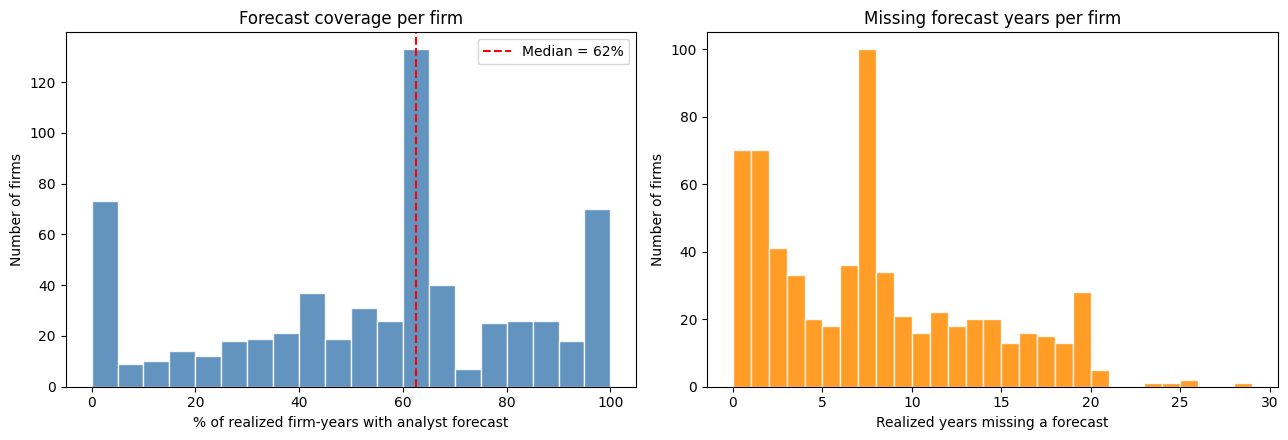

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(coverage["coverage_pct"], bins=20, color="steelblue", 
             edgecolor="white", alpha=0.85)
axes[0].axvline(coverage["coverage_pct"].median(), color="red", ls="--",
                label=f"Median = {coverage['coverage_pct'].median():.0f}%")
axes[0].set_xlabel("% of realized firm-years with analyst forecast")
axes[0].set_ylabel("Number of firms")
axes[0].set_title("Forecast coverage per firm")
axes[0].legend()

axes[1].hist(coverage["n_missing"], bins=range(0, int(coverage["n_missing"].max()) + 2),
             color="darkorange", edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Realized years missing a forecast")
axes[1].set_ylabel("Number of firms")
axes[1].set_title("Missing forecast years per firm")

plt.tight_layout()
plt.show()